In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from matplotlib.ticker import FuncFormatter
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import matplotlib.ticker as mticker
import math
import itertools
from typing import Literal
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import time
import joblib
import os
from sklearn.metrics import roc_curve
from sklearn.pipeline import Pipeline
from functools import partial
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score, precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, mutual_info_regression

In [2]:
from sklearn import set_config
set_config(transform_output='pandas', display='diagram')

In [3]:
data = pd.read_csv('/kaggle/input/data-for-mining/data_clean.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,...,1,0,5,18.0,15.0,1,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,...,0,1,3,0.0,0.0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,1,...,1,1,5,30.0,30.0,1,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,1,...,1,0,2,0.0,0.0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,1,...,1,0,2,3.0,0.0,0,0,11,5,4


In [4]:
# lấy 100000 mẫu dữ liệu phân tầng
X = data.drop(columns=['Diabetes_binary'])
y = data['Diabetes_binary']

X_sampled, _, y_sampled, _ = train_test_split(
    X,
    y,
    train_size=100_000,
    stratify=y,
    random_state=42
)

In [5]:
ordinal_cols = ["GenHlth", "Education", "Income", "AgeGroup"]

continuous_cols = ["BMI", "MentHlth", "PhysHlth"]

binary_columns = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
                  'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
                  'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

target_column = "Diabetes_binary"

In [6]:
# chia tập dữ liệu
X_train, X_val, y_train, y_val = train_test_split(X_sampled, y_sampled, stratify=y_sampled, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

In [7]:
class ConvertAge(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X: pd.Series, y=None):
        return self

    def transform(self, X: pd.Series):
        def map_age_group(age_code):
            if age_code <= 4:
                return "18–39"
            elif age_code <= 7:
                return "40–54"
            elif age_code <= 9:
                return "55–64"
            else:
                return "65+"

        agegroup_map = {
            "18–39": 1,
            "40–54": 2,
            "55–64": 3,
            "65+": 4
        }

        X = X.apply(map_age_group).map(agegroup_map)
        return X.to_frame(name="AgeGroup")

    def get_feature_names_out(self, input_features=None):
        return ["AgeGroup"]

In [8]:
convert_age = ColumnTransformer(
    transformers=
    [
        ("convert_age", ConvertAge(), 'Age'), 
    ],
    remainder='passthrough',
    verbose_feature_names_out=False, # not containing the transformer name in columns of Dataframe
    # force_int_remainder_cols=False
)

# Kiểm tra và diễn giải Mô hình

## Kiểm tra hiệu quả của mô hình

In [11]:
# Để kiểm tra độ hiệu quả, chất lượng của mô hình, ta sẽ dùng Precision-Recall curve và ROC-AUC curve
dt_tuned_model = joblib.load("/kaggle/input/decision-tree-fine-tuned/scikitlearn/default/1/dt_tuned_pipeline.joblib")
dt_tuned_model

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('convert_age',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('convert_age', ConvertAge(),
                                                  'Age')],
                                   verbose_feature_names_out=False)),
                ('dt',
                 DecisionTreeClassifier(class_weight={0: 1, 1: 10},
                                        min_samples_leaf=50,
                                        min_samples_split=20,
                                        random_state=42))])

In [31]:
class PrecisionRecallCurve:
    def __init__(self, X:pd.DataFrame, y:pd.Series):
        self.x = X
        self.y = y

    def compute_average_precision_score(self, estimators_dict:dict, tree_models:bool):
        estimators_score = {}
        for estimator_name, estimator in estimators_dict.items():
            y_score = estimator.predict_proba(self.x)[:, 1] # certainty measure for the positive class (class 1)
            ap_score = average_precision_score(self.y, y_score)
            estimators_score[estimator_name] = ap_score
        return estimators_score
    
    def plot_precision_recall_curve(self, estimators_dict:dict, plots_each_row:int, tree_models:bool):
        num_plots = len(estimators_dict)
        number_rows = math.ceil(num_plots / plots_each_row)
        
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),) # sharey=True
        axes = np.array(axes).reshape(number_rows, plots_each_row)
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
        
        for coor, (estimator_name, estimator) in zip(coordinates, estimators_dict.items()):
            y_score = estimator.predict_proba(self.x)[:, 1] # certainty measure for the positive class (class 1)
            precision, recall, thresholds = precision_recall_curve(self.y, y_score)
            close_zero = np.argmin(np.abs(thresholds - 0.5))
            
            axes[coor].plot(precision, recall, label=estimator_name)
            axes[coor].plot(precision[close_zero], recall[close_zero], 'o', markersize=4, label=f"{estimator_name} default threshold", fillstyle="none", c='k', mew=2)
            axes[coor].set_xlabel("Precision")
            axes[coor].set_ylabel("Recall")
            axes[coor].legend(loc="best")
            axes[coor].set_ylim([0, 1])
            axes[coor].grid()

        # hide any unused axes
        for coor in coordinates[num_plots:]:
            fig.delaxes(axes[coor])

    def plot_precision_recall_with_thresholds(self, estimators_dict:dict, plots_each_row:int, tree_models:bool):
        num_plots = len(estimators_dict)
        number_rows = math.ceil(num_plots / plots_each_row)
        
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),) # sharey=True
        axes = np.array(axes).reshape(number_rows, plots_each_row)
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))

        for coor, (estimator_name, estimator) in zip(coordinates, estimators_dict.items()):
            y_score = estimator.predict_proba(self.x)[:, 1] # certainty measure for the positive class (class 1)
            precision, recall, thresholds = precision_recall_curve(self.y, y_score)

            axes[coor].axvline(x=0.5, color="red", linestyle=":", linewidth=2, label=f"{estimator_name}'s Default Threshold")
            axes[coor].plot(thresholds, precision[:-1], "b--", label="Precision")
            axes[coor].plot(thresholds, recall[:-1], "g-", label="Recall")
            axes[coor].set_xlabel("Threshold")
            axes[coor].set_title(estimator_name)
            axes[coor].legend(loc="best")
            axes[coor].set_ylim([0, 1])
            axes[coor].grid()

        # hide any unused axes
        for coor in coordinates[num_plots:]:
            fig.delaxes(axes[coor])

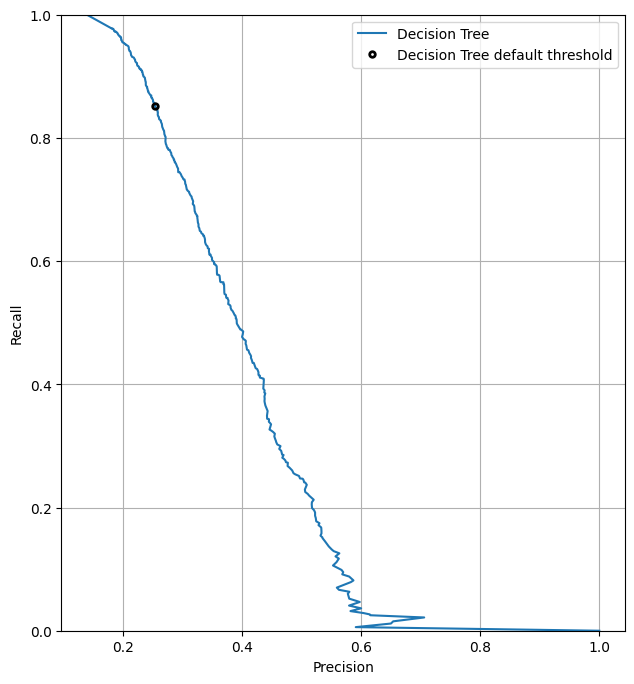

In [32]:
precision_recall = PrecisionRecallCurve(X_test, y_test)

estimators_dict={
    'Decision Tree': dt_tuned_model
}
plots_each_row=2
tree_models=True

precision_recall.plot_precision_recall_curve(estimators_dict, plots_each_row, tree_models)

# Từ biểu đồ Precision-Recall có thể nhận thấy một sự đánh đổi đáng kể giữa recall và precision
# khi recall càng tăng thì precision có xu hướng sẽ giảm xuống
# Nhìn vào đường này, ta thấy được đường Precision-Recall khá dốc, đồng nghĩa với mô hình không
# thật sự học tốt trên tập dữ liệu khi chỉ cần cố gắng tăng điểm Recall thì Precision sẽ giảm đi đáng kể

In [33]:
# Tính điểm cho phần diện tích nằm dưới đường cong PR ở trên
estimators_dict={
    'Decision Tree': dt_tuned_model
}
tree_models=True

scores = precision_recall.compute_average_precision_score(estimators_dict, tree_models)
print(f"Điểm Average Precision của Decision Tree là: {scores['Decision Tree']}")

# Dựa vào điểm số này ta nhận thấy mô hình đã train học không thật sự tốt và chưa đủ chất lượng
# khi có điểm AP thấp, điều này được lí giải là bởi mô hình chú trọng vào việc tăng điểm recall
# nhưng điều này làm giảm điểm presicion đi -> điểm AP sẽ thấp

Điểm Average Precision của Decision Tree là: 0.39289870801199417


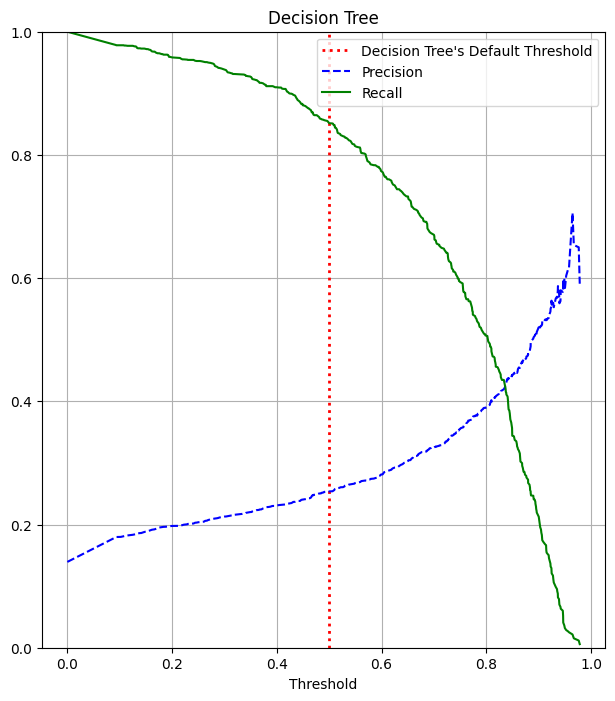

In [34]:
estimators_dict={
    'Decision Tree': dt_tuned_model
}
plots_each_row=2
tree_models=True

precision_recall.plot_precision_recall_with_thresholds(estimators_dict, plots_each_row, tree_models)
# Tại threshold là xấp xỉ 0.82 thì precision và recall ngang nhau đối với Decision Tree

In [52]:
# Tiếp theo ta sẽ đến với đường cong ROC (Receiver operating characteristic)
class ROCCurve:
    def __init__(self, X:pd.DataFrame, y:pd.Series):
        self.x = X
        self.y = y

    def plot_roc_curve_with_thresholds(self, estimators_dict:dict, plots_each_row:int, tree_models:bool):
        num_plots = len(estimators_dict)
        number_rows = math.ceil(num_plots / plots_each_row)
        
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),) # sharey=True
        axes = np.array(axes).reshape(number_rows, plots_each_row)
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))

        for coor, (estimator_name, estimator) in zip(coordinates, estimators_dict.items()):
            y_score = estimator.predict_proba(self.x)[:, 1] # certainty measure for the positive class (class 1)
            fpr, tpr, thresholds = roc_curve(self.y, y_score)

            axes[coor].axvline(x=0.5, color="red", linestyle=":", linewidth=2, label=f"{estimator_name}'s Default Threshold")
            axes[coor].plot(thresholds, fpr, "b--", label="FPR")
            axes[coor].plot(thresholds, tpr, "g-", label="TPR (recall)")
            axes[coor].set_xlabel("Threshold")
            axes[coor].set_title(estimator_name)
            axes[coor].legend(loc="best")
            axes[coor].set_ylim([0, 1])
            axes[coor].grid()

        # hide any unused axes
        for coor in coordinates[num_plots:]:
            fig.delaxes(axes[coor])
    
    def plot_roc_curve(self, estimators_dict:dict, plots_each_row:int, tree_models:bool):
        num_plots = len(estimators_dict)
        number_rows = math.ceil(num_plots / plots_each_row)
        
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),) # sharey=True
        axes = np.array(axes).reshape(number_rows, plots_each_row)
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))

        for coor, (estimator_name, estimator) in zip(coordinates, estimators_dict.items()):
            y_score = estimator.predict_proba(self.x)[:, 1]
            fpr, tpr, thresholds = roc_curve(self.y, y_score)
            close_zero = np.argmin(np.abs(thresholds - 0.5))
            
            axes[coor].plot(fpr, tpr, label=f"{estimator_name}'s ROC Curve")
            axes[coor].set_xlabel("FPR")
            axes[coor].set_ylabel("TPR (recall)")
            axes[coor].plot(fpr[close_zero + 1], tpr[close_zero + 1], 'o', markersize=4, label=f"{estimator_name} default threshold", fillstyle="none", c='k', mew=2)
            axes[coor].plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), "b--", label=f"Random Classifier")
            axes[coor].legend(loc='best')
            axes[coor].grid()

        # hide any unused axes
        for coor in coordinates[num_plots:]:
            fig.delaxes(axes[coor])

    def compute_auc_score(self, estimators_dict:dict, tree_models:bool):
        estimators_score = {}
        for estimator_name, estimator in estimators_dict.items():
            y_score = estimator.predict_proba(self.x)[:, 1] # certainty measure for the positive class (class 1)
            auc_score = roc_auc_score(self.y, y_score)
            estimators_score[estimator_name] = auc_score
        return estimators_score

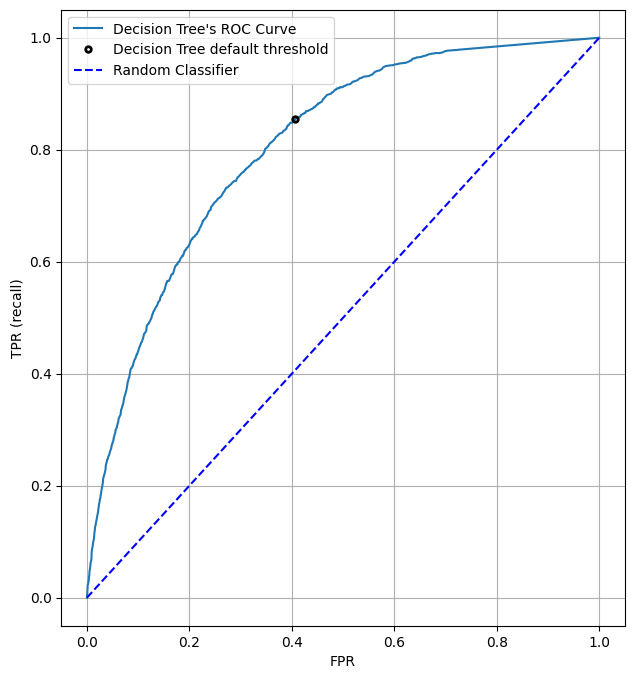

In [53]:
roc_curve_plotter = ROCCurve(X_test, y_test)

estimators_dict={
    'Decision Tree': dt_tuned_model
}
tree_models=True
plots_each_row=2

roc_curve_plotter.plot_roc_curve(estimators_dict, plots_each_row, tree_models)

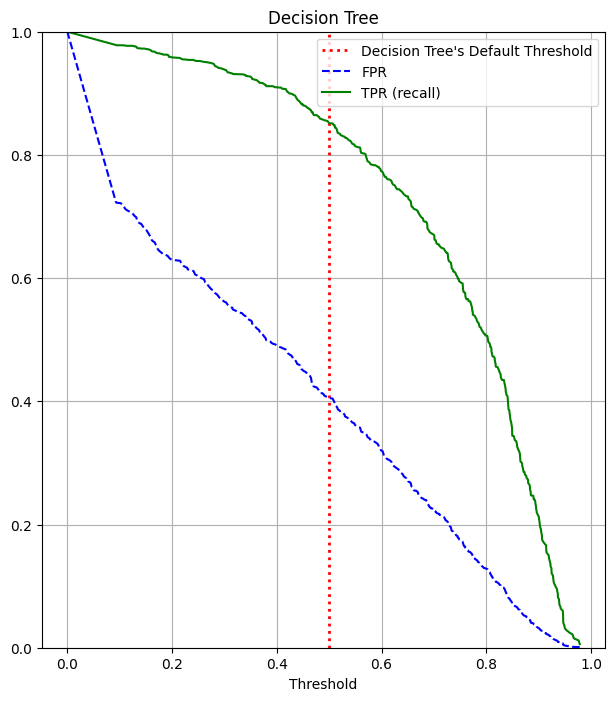

In [50]:
estimators_dict={
    'Decision Tree': dt_tuned_model
}
tree_models=True
plots_each_row=2

roc_curve_plotter.plot_roc_curve_with_thresholds(estimators_dict, plots_each_row, tree_models)

In [51]:
estimators_dict={
    'Decision Tree': dt_tuned_model
}
tree_models=True

score = roc_curve_plotter.compute_auc_score(estimators_dict, tree_models)
print(f"Điểm AUC của Decision Tree là: {score['Decision Tree']}")

# Điểm AUC cao -> mô hình rất tốt trong việc dự đoán positive đối với những người thật sự là positive
# cũng như ít nhầm lẫn trong việc dự đoán positive đối với những người thật sự là negative

Điểm AUC của Decision Tree là: 0.805547554941091


## Diễn giải mô hình

In [ ]:
# Kiểm tra những đặc trưng mà Decision Tree cho là quan trọng
def plot_feature_importances(estimators_dict:dict, plots_each_row:int):
    num_plots = len(estimators_dict)
    number_rows = math.ceil(num_plots / plots_each_row)
        
    fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 8),) # sharey=True
    axes = np.array(axes).reshape(number_rows, plots_each_row)
    coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
    for coor, (estimator_name, estimator) in zip(coordinates, estimators_dict.items()):
        series = pd.Series(
            data = estimator.feature_importances_,
            index = estimator.feature_names_in_
        )
        n_features = series.shape[0]
        colors = plt.cm.tab20(np.linspace(0, 1, n_features))
        
        bars = axes[coor].barh(range(n_features), series.values, align='center', color=colors, edgecolor="black")
        axes[coor].set_yticks(np.arange(n_features), series.index, fontsize=10)
        
        axes[coor].set_xlabel("Feature importance", fontsize=12, weight='bold')
        axes[coor].set_ylabel("Feature", fontsize=12, weight='bold')
        axes[coor].set_title(estimator_name, fontsize=14, weight='bold')

        # Add gridlines for better contrast
        axes[coor].grid(axis='x', linestyle='--', alpha=0.6)
    
        # Add value labels on bars
        for bar in bars:
            axes[coor].text(bar.get_width() + 0.002, 
                     bar.get_y() + bar.get_height()/2, 
                     f"{bar.get_width():.3f}",
                     va='center', fontsize=9, color='black')

    # hide any unused axes
    for coor in coordinates[num_plots:]:
        fig.delaxes(axes[coor])

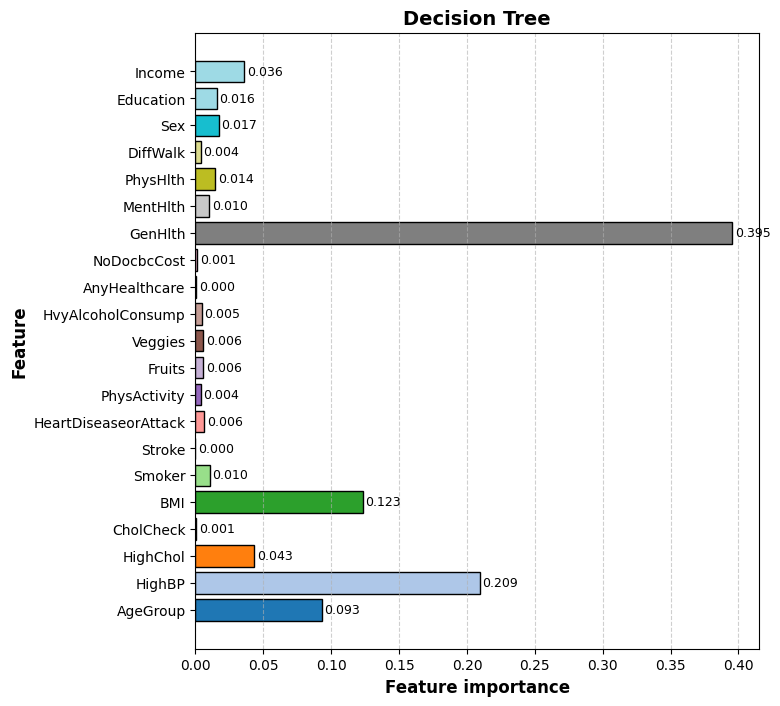

In [13]:
dt_ = dt_tuned_model[-1]

estimators_dict={
    'Decision Tree': dt_,
}
plots_each_row=2

plot_feature_importances(estimators_dict, plots_each_row)

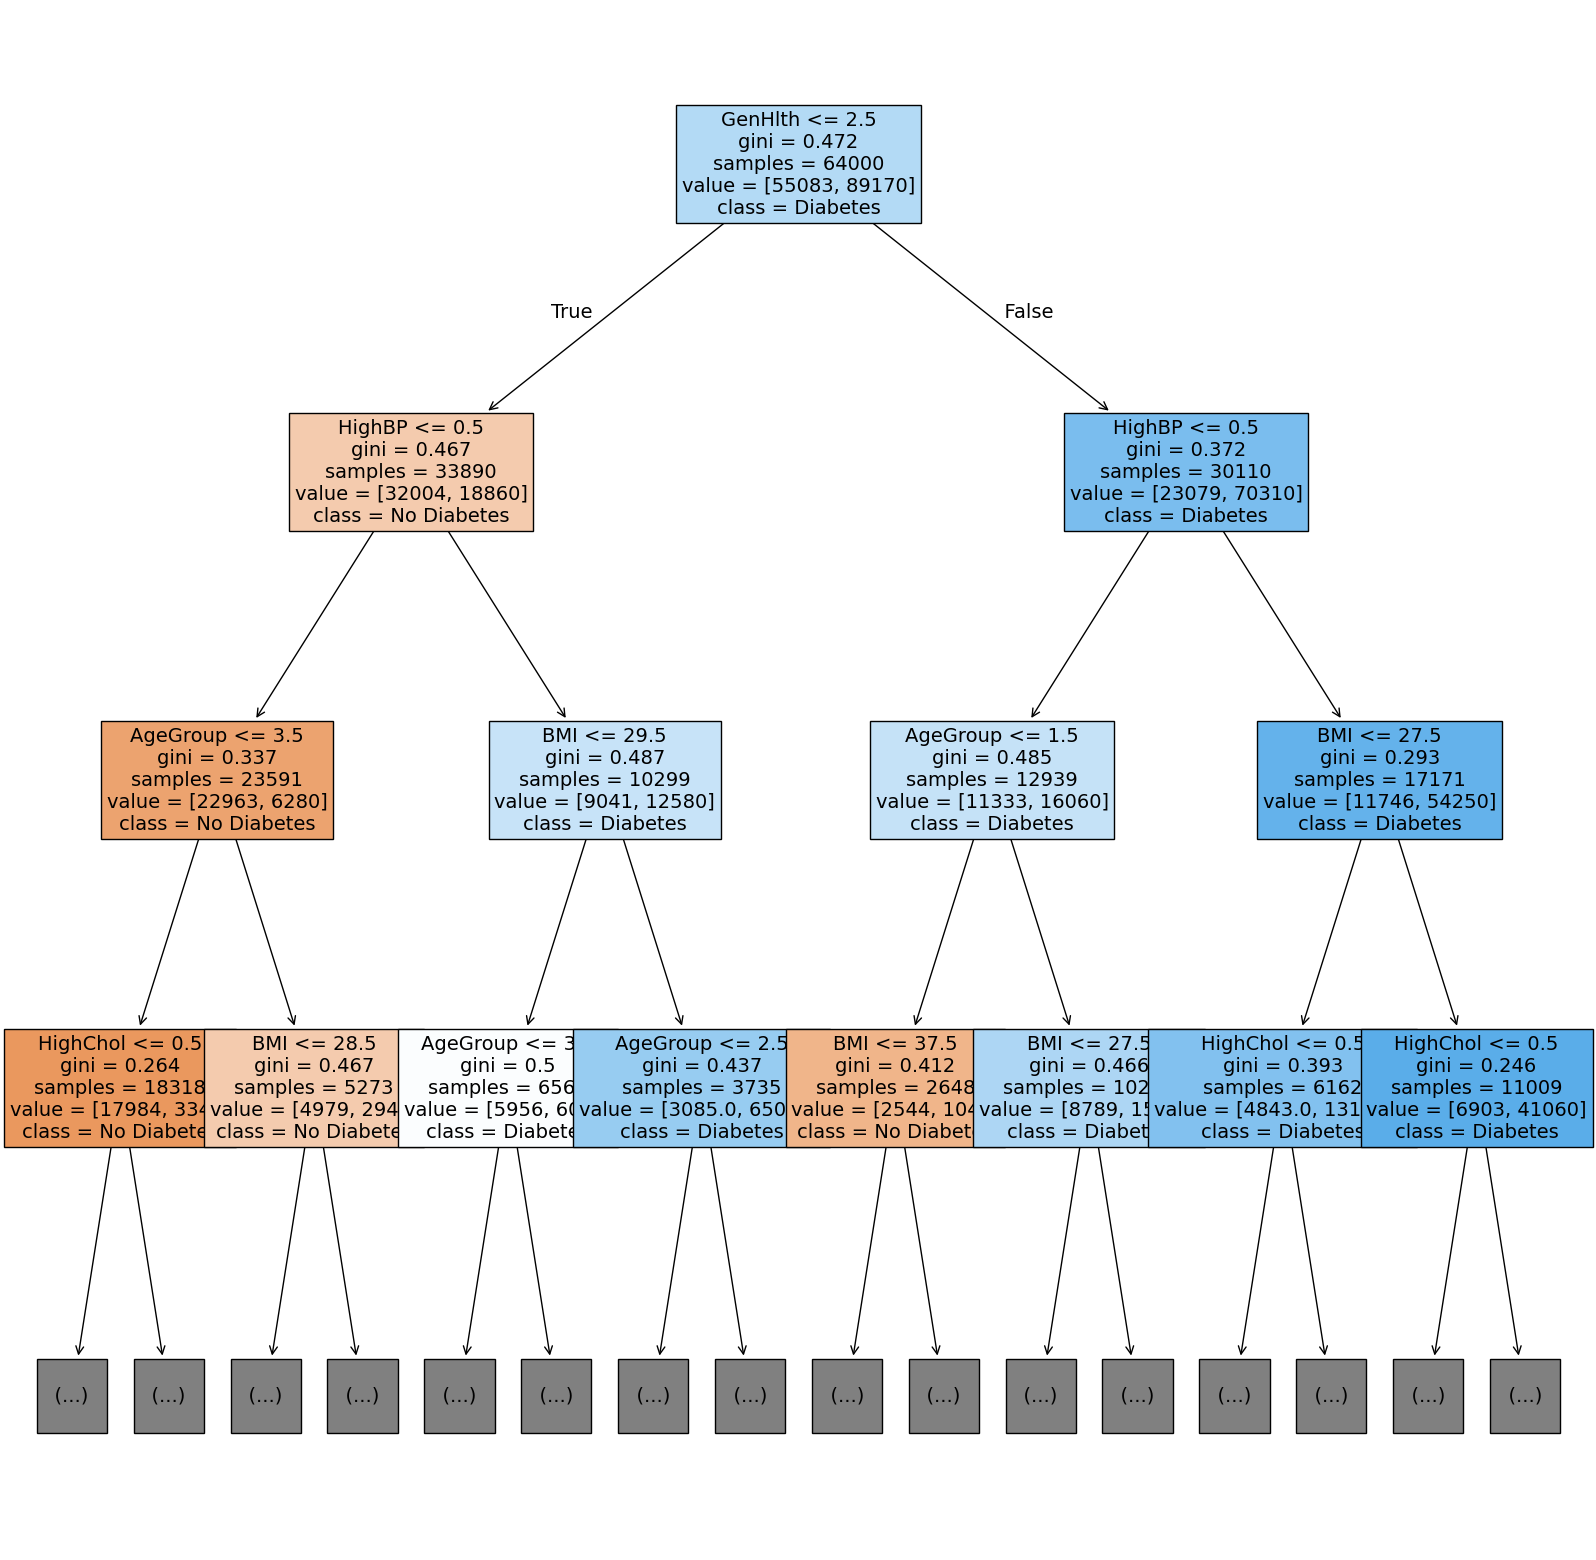

In [ ]:
# Ming hoạ cách Decision Tree đưa ra quyết định
plt.figure(figsize=(20,20))
dt_ = dt_tuned_model[-1]
plot_tree(dt_, max_depth=3, fontsize=14, feature_names=dt_.feature_names_in_, 
          class_names={0:'No Diabetes', 1:'Diabetes'}, filled=True, impurity=True)

plt.show()